# 1. Preparación de datos

In [64]:
# Importe de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

## Carga de Datos

In [65]:
url = "https://raw.githubusercontent.com/Octaviochavez/analitica_clientes/main/data/dataset_clientes.csv"

In [66]:
# Lectura de datos sucios del dataset desde directorio local data
data = pd.read_csv(url)
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


## 1.1 Limpieza y Transformación de Datos

### Clases y Funciones necesarias

In [68]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Eliminación de variables correlacionadas compatible con Pipelines de Scikit-Learn.
    """
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        # 1. Asegurar que trabajamos con un DataFrame y forzar tipos numéricos
        if not isinstance(X, pd.DataFrame):
            X_df = pd.DataFrame(X)
        else:
            X_df = X
            
        X_df = X_df.apply(pd.to_numeric, errors='coerce')

        # 2. Calcular matriz de correlación
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # 3. Identificar nombres o índices de columnas a eliminar
        self.columns_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]

        # 4. Crear una máscara booleana (LA MEJOR PRÁCTICA PARA SCIKIT-LEARN)
        # Esto permite filtrar tanto DataFrames como arrays de NumPy de forma segura.
        self.features_to_keep_mask_ = np.array([
            col not in self.columns_to_drop_ for col in X_df.columns
        ])

        # 5. Guardar nombres de columnas si la entrada original era DataFrame
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.array(X.columns)

        return self

    def transform(self, X):
        # Aplicamos la máscara de filtrado dependiendo del tipo de dato de entrada
        if isinstance(X, pd.DataFrame):
            return X.loc[:, self.features_to_keep_mask_]
        else:
            return X[:, self.features_to_keep_mask_]

    def get_feature_names_out(self, input_features=None):
        """
        Método crucial para que el pipeline sepa qué columnas sobrevivieron.
        """
        if hasattr(self, 'feature_names_in_'):
            return self.feature_names_in_[self.features_to_keep_mask_]
        elif input_features is not None:
            return np.array(input_features)[self.features_to_keep_mask_]
        else:
            # Fallback si no hay nombres disponibles
            return np.arange(len(self.features_to_keep_mask_))[self.features_to_keep_mask_].astype(str)

In [69]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [70]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
  """
  Ingeniería de características

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  Returns
  -------
  DataFrame
    Conjunto de datos con nuevas características.
  """
  def __init__(self):
    pass

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    
    # razón de endeudamiento
    X["ratio_endeudamiento"] = X["deuda_total"] / X["ingreso_mensual"]

    # porcentaje de gasto respecto al ingreso
    X['porcentaje_gasto'] = X['gasto_mensual'] / X['ingreso_mensual']
    
    return X

In [71]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        # Calculamos y guardamos los límites matemáticos AQUÍ (Fase de aprendizaje)
        self.lower_bounds_ = X_df.quantile(self.limits[0])
        self.upper_bounds_ = X_df.quantile(1 - self.limits[1])
        self.columns_ = X_df.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        X_df = X_df.astype("float64")
        # Aplicamos los límites guardados
        for col in self.columns_:
            X_df[col] = np.clip(X_df[col], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_df

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

In [72]:
# Define función para eliminar duplicados

def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [73]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

### Detección de inconsistencias

In [74]:
# Deteccion de inconsistencias: negativos o ceros en columnas que deberian ser positivas
columnas_negativas_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]
columnas_ceros_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses",
]

conteo_negativos = {}
conteo_ceros = {}
for col in columnas_negativas_check:
    if col in data.columns:
        conteo_negativos[col] = int((data[col] < 0).sum())
for col in columnas_ceros_check:
    if col in data.columns:
        conteo_ceros[col] = int((data[col] == 0).sum())

conteo_negativos = {k: v for k, v in conteo_negativos.items() if v > 0}
conteo_ceros = {k: v for k, v in conteo_ceros.items() if v > 0}

print("Negativos detectados:", conteo_negativos if conteo_negativos else "ninguno")
print("Ceros detectados:", conteo_ceros if conteo_ceros else "ninguno")

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [75]:
# Tratamiento: corrige valores negativos convirtiendolos a valor absoluto
columns_to_correct = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]

for col in columns_to_correct:
    if col in data.columns:
        data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


### Construcción de arrays para procesamiento

In [76]:
numerical_features = ["ratio_endeudamiento", "porcentaje_gasto", "gasto_mensual", "score_crediticio", "ingreso_mensual", "deuda_total", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
categorical_nominales = ["tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro","dia_semana_registro"] # Define listado de variables categóricas nominales
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora
orden_tipo_plan = ['Basico', 'Estandar', 'Premium'] # Define orden para variable ordinal tipo_plan
orden_uso_app = ['Bajo', 'Medio', 'Alto'] # Define orden para variable ordinal uso_app

### Pipelines para cada tipo de conjunto


In [77]:
# Define pipeline para variables numéricas
pipeline_numerical_features = Pipeline(steps=[
    ('winsorizer', Winsorizer(limits=(0.05, 0.05))), # Aplica Winsorización para limitar outliers al 5%
    ('imputer', SimpleImputer(strategy='mean')), # Imputa valores faltantes con el promedio
    ('scaler', StandardScaler()) # Escala características numéricas
])

In [78]:
# Define pipeline para variables categóricas nominales
pipeline_nominales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Aplica codificación OneHotEncoder para variables nominales
])

In [79]:
# Define pipeline para variables categóricas ordinales
pipeline_ordinales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('ordinal', OrdinalEncoder(categories=[orden_tipo_plan, orden_uso_app])) # Aplica codificación OrdinalEncoder para variables ordinales con orden definido
])

### Integración de pipelines de transformación


In [80]:
# Combina pipelines para aplicar transformaciones específicas a cada tipo de variable
preprocesador = ColumnTransformer(
    transformers=[
        ('num_limpios', pipeline_numerical_features, numerical_features),
        ('cat_nom', pipeline_nominales, categorical_nominales),
        ('cat_ord', pipeline_ordinales, categorical_ordinales),
    ],
    remainder='drop' # Elimina columnas no especificadas
)

### Elimina duplicados y separa objetivo/features para mantener alineacion

In [81]:
data_sin_dup = tratar_duplicados(data, drop=True).reset_index(drop=True)
var_dep = data_sin_dup["abandono"].reset_index(drop=True)
var_indep = data_sin_dup.drop(columns=["abandono"])

### Pipeline para Regresión Logística


In [95]:
# Define pipeline de limpieza de datos que incluye eliminación de duplicados, ingeniería de características y preprocesamiento específico para cada tipo de variable
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": True})), # Elimina duplicados del dataset
        ("feature_engineering", FeatureEngineering()), # Agrega nuevas características
        ("preprocesamiento", preprocesador),
        ("conversion", DataFrameConverter(preprocesador)) # Convierte la salida a DataFrame con nombres
    ]
)
pipeline_modelo_lr = Pipeline( # Define pipeline para regresión logística que incluye eliminación de variables correlacionadas y el modelo de regresión logística
    steps = [
        ("colinealidad", CorrelationFilter(threshold = 0.9)), # Elimina variables altamente correlacionadas
        ("modelo", LogisticRegression(max_iter = 1000)) # Agrega modelo de regresión logística
    ]
)

In [96]:
# Aplica pipeline de limpieza al dataset y obtiene el resultado transformado
data_transformada = pipeline_limpieza.fit_transform(var_indep)
data_transformada.columns = data_transformada.columns.str.replace("num_limpios__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_nom__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_ord__", "")
data_transformada["abandono"] = var_dep.to_numpy()
data_transformada.head()

,ratio_endeudamiento,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,deuda_total,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
0,-0.087339,8.917517e-02,0.928655,-1.616594,5.299850e-01,0.572683,0.995847,1.213020,-0.724598,1.589155,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,-1.135785,-1.246435e+00,-0.634528,-0.283686,1.882364e+00,-0.532574,0.141534,0.142729,-0.358339,1.202924,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0
2,0.000000,4.360560e-16,-0.091194,1.852509,5.168572e-16,1.849046,-0.029329,-1.581629,0.374180,0.478739,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0
3,2.483183,1.613845e+00,0.133315,-1.757904,-1.633970e+00,1.308836,0.312397,-1.581629,-1.273987,-0.168199,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1
4,-0.398030,4.649992e-01,0.681864,-1.474195,-2.844893e-01,-0.509680,-0.997550,-1.373516,-0.907728,0.971185,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1


In [97]:
import os

# definir la ruta relativa: subir un nivel (..) y luego entrar en 'data'
target_dir = os.path.join('..', 'data')
file_name = 'dataset_clientes_limpio.csv'
full_path = os.path.join(target_dir, file_name)

# asegurar que la carpeta 'data' existe en el nivel superior
# os.makedirs creará la carpeta si no existe
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)
    print(f"Directorio creado o verificado en: {os.path.abspath(target_dir)}")

# guardar el DataFrame
data_transformada.to_csv(full_path, index=False, encoding='utf-8')

print(f"Archivo guardado exitosamente en: {full_path}")

Archivo guardado exitosamente en: ..\data\dataset_clientes_limpio.csv


# 2. Modelamiento

## 2.1 Entendimiento de los datos

In [85]:
target = 'abandono'

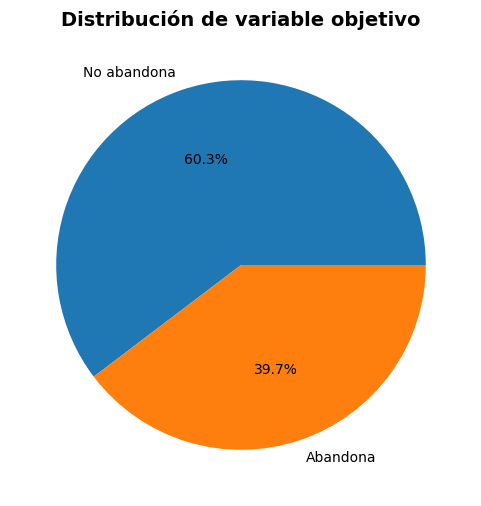

In [98]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data_transformada[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

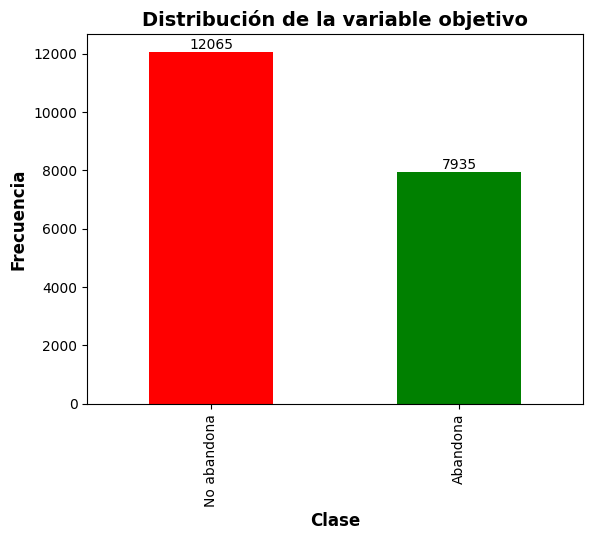

In [99]:
# Grafica la distribución de la variable objetivo
data_transformada[target].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Distribución de la variable objetivo", fontweight="bold", fontsize=14)
plt.xlabel("Clase", fontweight="bold", fontsize=12)
plt.ylabel("Frecuencia", fontweight="bold", fontsize=12)
# Agrega los nombres de las clases en el eje (0 = No, 1 = Si)
plt.xticks([0, 1], ["No abandona", "Abandona"])
# Agrega las etiquetas a cada clase
for i, count in enumerate(data_transformada[target].value_counts()):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()

## 2.2 Modelo de Regresión Logística

### Modelo 1

In [100]:
# Calcula la matriz de correlaciones
correlaciones = data_transformada.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

abandono                         1.000000
ultima_compra_dias               0.212568
deuda_total                      0.032325
ratio_endeudamiento              0.019814
dia_semana_registro_Jueves       0.012692
region_Sur                       0.010814
dia_semana_registro_Lunes        0.008319
dia_semana_registro_Martes       0.007734
hora_registro                    0.007570
canal_registro_Tienda            0.007372
edad                             0.006443
genero_Otro                      0.005531
region_Centro                    0.005515
estado_civil_Divorciado          0.004422
ingreso_mensual                  0.003754
dia_semana_registro_Domingo      0.001531
tiene_tarjeta_credito_0          0.000173
tiene_tarjeta_credito_1         -0.000173
canal_registro_App              -0.000696
genero_Masculino                -0.001049
estado_civil_Soltero            -0.001378
num_productos                   -0.002758
estado_civil_Casado             -0.003035
dia_semana_registro_Sabado      -0

#### Variables

In [101]:
X = data_transformada.drop(columns=[target])
y = data_transformada[target]

#### División train/test


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=29, stratify = y)

#### Evaluación


In [103]:
modelo = pipeline_modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]  # probabilidades clase positiva

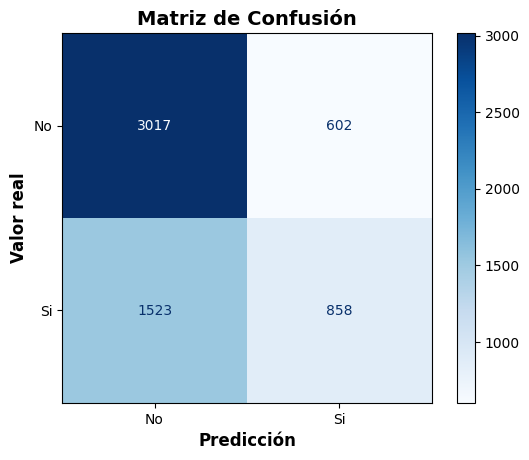

In [104]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Si"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [105]:
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")

Accuracy            : 0.6458
F1 Score:           : 0.4468
ROC AUC Score       : 0.6719


In [106]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.65057
Score del modelo en test                :0.64583


### Modelo 2